# Presentation Figures

Large, slide-ready figures for the week of **1–7 July 2024**.

1. True electricity price only (blue)
2. True price + XGBoost prediction (orange dashed)

Figures are saved as high-res PNGs next to this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor

In [2]:
MODEL_PATH = "./xgb_v4_OTA2201_20260602_1457.ubj"

model = XGBRegressor()
model.load_model(MODEL_PATH)
print("Model loaded.")

Model loaded.


In [3]:
# Load + preprocess — identical to v4_search / load_and_test

df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)
df = df.ffill()

target_col = "el_price_dol_MWh_OTA2201"

cols_to_shift_24h = [
    c for c in df.columns if "el_price" in c and c != target_col
] + [
    "Coal","Diesel","Ele","Gas","Geo","Hydro","Solar","Wind","Wood",
    "demand_GWh_CNI","demand_GWh_LNI","demand_GWh_LSI","demand_GWh_UNI","demand_GWh_USI",
    "avg_flow_MW","peak_flow_MW","Direction"
]
for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]    = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]    = np.cos(2*np.pi*df["dayofweek"]/7)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window).std()

df = df.dropna().reset_index(drop=True)

exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]
print("Ready —", df.shape)

Ready — (43825, 101)


In [4]:
# Extract 1–7 July 2024 and predict

START = "2024-07-01"
END   = "2024-07-08"   # exclusive → 7 full days

mask = (df["datetime_utc12"] >= START) & (df["datetime_utc12"] < END)
wk = df[mask].reset_index(drop=True)

ts     = wk["datetime_utc12"]
actual = wk[target_col].values
pred   = np.clip(model.predict(wk[feature_cols].values), 0, None)

print(f"{len(wk)} hours  |  {ts.iloc[0]} → {ts.iloc[-1]}")

168 hours  |  2024-07-01 00:00:00 → 2024-07-07 23:00:00


In [5]:
# Presentation styling — large fonts, thick lines

plt.rcParams.update({
    "font.size":        20,
    "axes.titlesize":   26,
    "axes.labelsize":   22,
    "xtick.labelsize":  18,
    "ytick.labelsize":  18,
    "legend.fontsize":  20,
    "axes.linewidth":   1.5,
    "figure.dpi":       110,
})

BLUE   = "#1f6feb"
ORANGE = "#ff8c1a"

def style_axes(ax):
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25, linewidth=1)
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

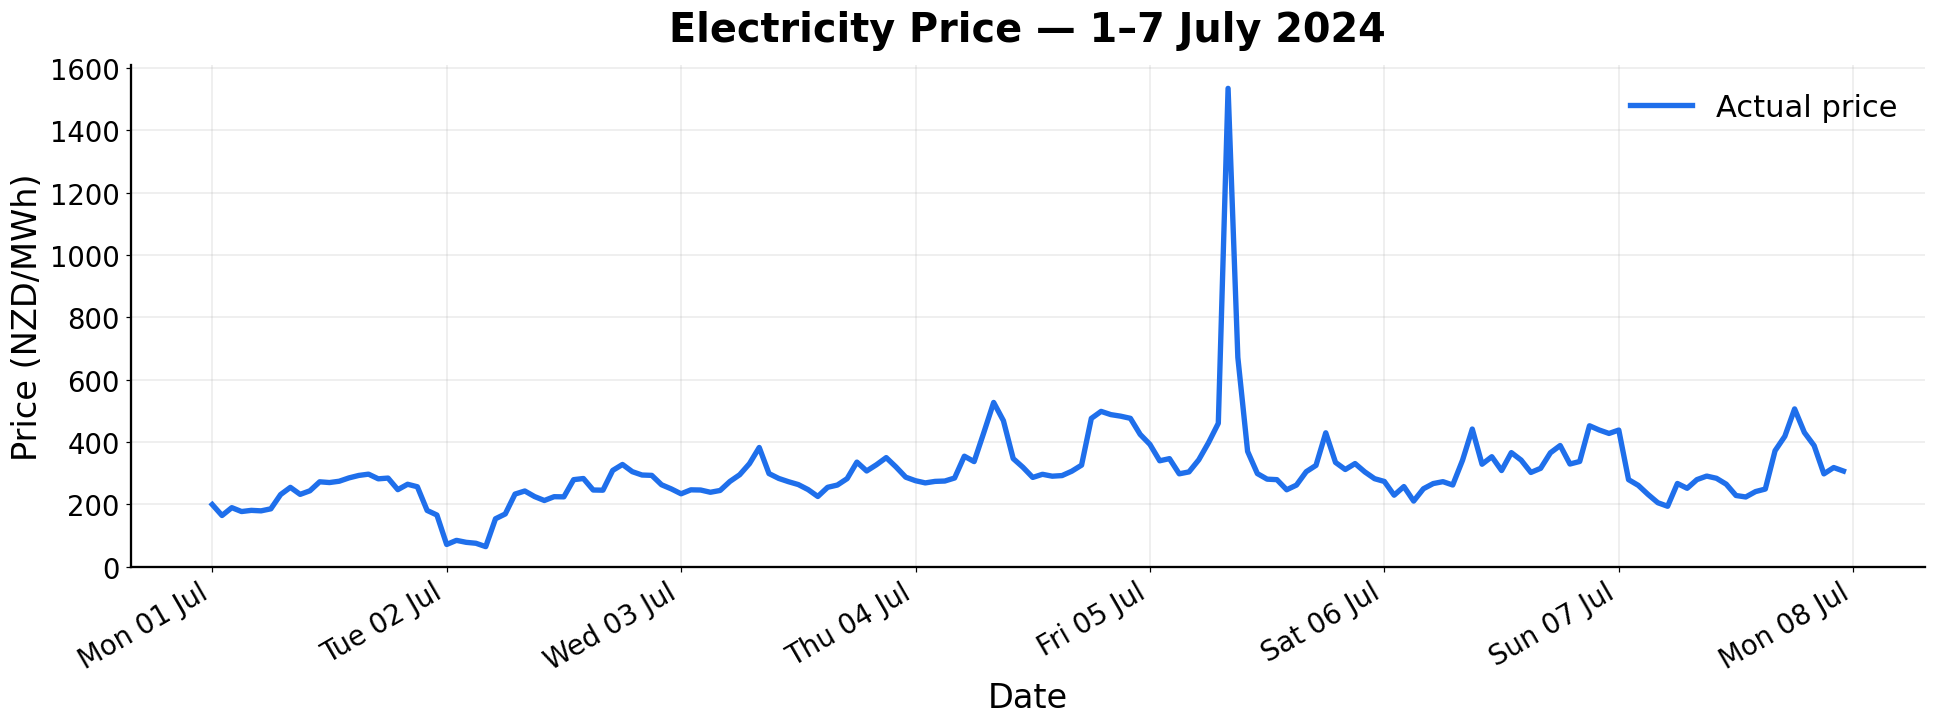

Saved figure_1_actual.png


In [6]:
# ── Figure 1 — True price only ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(ts, actual, color=BLUE, linewidth=3.5, label="Actual price")

ax.set_title("Electricity Price — 1–7 July 2024", fontweight="bold", pad=16)
style_axes(ax)
ax.legend(loc="upper right", frameon=False)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_1_actual.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure_1_actual.png")

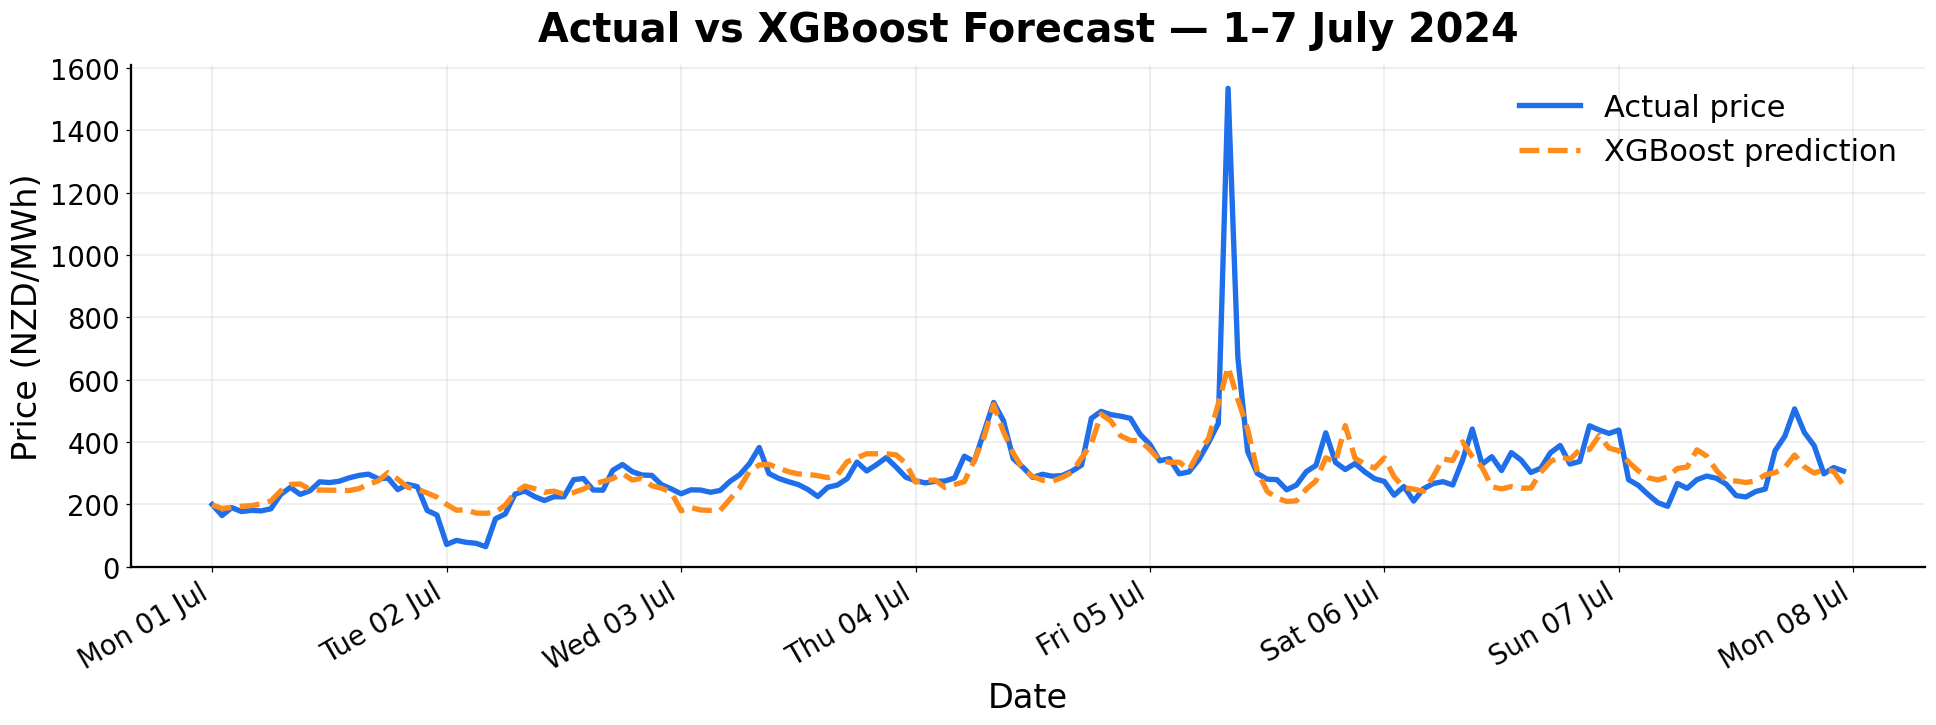

Saved figure_2_actual_vs_pred.png


In [7]:
# ── Figure 2 — True price + XGBoost prediction ───────────────────────────────

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(ts, actual, color=BLUE,   linewidth=3.5, label="Actual price")
ax.plot(ts, pred,   color=ORANGE, linewidth=3.5, linestyle="--",
        label="XGBoost prediction")

ax.set_title("Actual vs XGBoost Forecast — 1–7 July 2024", fontweight="bold", pad=16)
style_axes(ax)
ax.legend(loc="upper right", frameon=False)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig("figures/figure_2_actual_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure_2_actual_vs_pred.png")